- `pyplot` 방식: `matplotlib.pyplot`에 있는 함수를 사용하는 방식  
- `객체지향 API` 방식: 명시적으로 피겨 객체와 서브플롯 객체를 만들고 이 객체의 메서드를 사용하는 방식

In [1]:
import matplotlib.pyplot as plt 
plt.rcParams['figure.dpi'] = 100

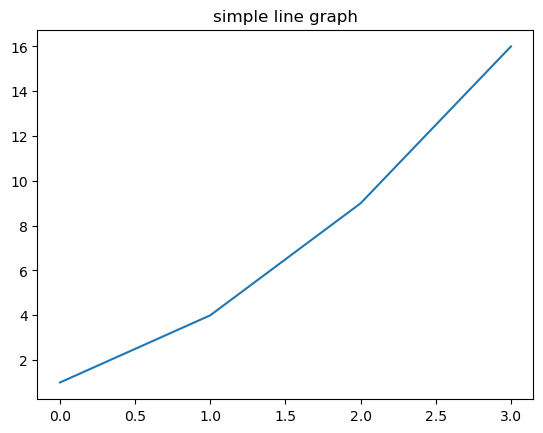

In [2]:
# pyplot 방식
plt.plot([1,4,9,16])    # 리스트의 인덱스가 자동으로 x축의 값으로 사용됨, 리스트 원소는 y축의 값
plt.title('simple line graph')
plt.show()

- 하나의 피겨에 여러 개의 서브플롯을 추가하는 등의 복잡한 그래프를 그리는 경우에는 객체지향 방식이 우세

C:\Users\user\AppData\Local\Temp\ipykernel_20340\2822645904.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


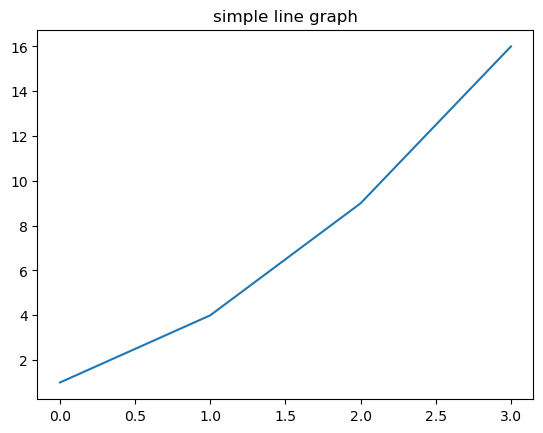

In [3]:
# 객체지향 api 방식
fig, ax = plt.subplots()
ax.plot([1,4,9,16])
ax.set_title('simple line graph')
fig.show()

- `rcParams` 객체의 `font.family` 속성을 통해 폰트 지정 가능

In [26]:
print(plt.rcParams['font.family'])
plt.rcParams['font.family'] = 'Malgun Gothic'

['Malgun Gothic']


- `rc()` 함수의 첫번째 매개변수에 `font`, 두번째 매개변수에 `family`를 지정하여 폰트 지정 가능

In [25]:
plt.rc('font', family='Malgun Gothic', size=11)

In [27]:
print(plt.rcParams['font.family'], plt.rcParams['font.size'])

['Malgun Gothic'] 11.0


In [23]:
import matplotlib.font_manager as fm
fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name or 'Gothic' in f.name]
print(set(fonts))

{'Century Gothic', 'HYGothic-Extra', 'Malgun Gothic', 'Copperplate Gothic Light', 'Franklin Gothic Heavy', 'Yu Gothic', 'HYGothic-Medium', 'Franklin Gothic Medium', 'MS Gothic', 'Franklin Gothic Demi Cond', 'Franklin Gothic Book', 'Showcard Gothic', 'Franklin Gothic Medium Cond', 'Franklin Gothic Demi', 'Copperplate Gothic Bold'}


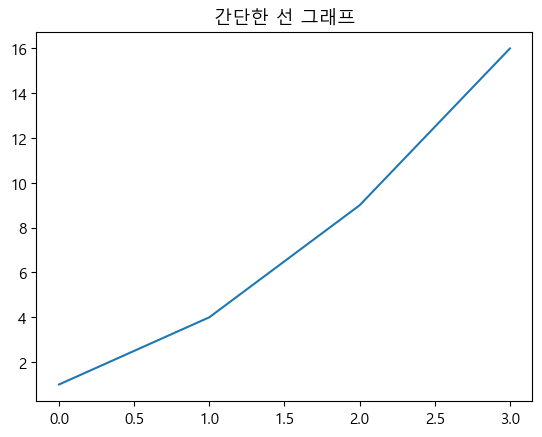

In [28]:
# 한글이 깨지지 않음
plt.plot([1,4,9,16])   
plt.title('간단한 선 그래프')
plt.show()

In [30]:
import pandas as pd
ns_book7 = pd.read_csv('ns_book7.csv', low_memory=False)
top30_pubs = ns_book7['출판사'].value_counts()[:30]
top30_pubs

출판사
문학동네           4410
민음사            3349
김영사            3246
웅진씽크빅          3227
시공사            2685
창비             2469
문학과지성사         2064
위즈덤하우스         1981
학지사            1877
한울             1553
한국학술정보         1496
열린책들           1491
살림출판사          1479
한길사            1460
博英社            1458
커뮤니케이션북스       1445
지식을만드는지식       1390
자음과모음          1364
비룡소            1331
랜덤하우스코리아       1314
넥서스            1310
황금가지           1101
길벗             1094
시그마프레스         1063
현암사            1054
다산북스           1046
집문당            1038
책세상            1037
한국문화사          1028
북이십일 21세기북스    1026
Name: count, dtype: int64

- `isin()` 메서드: 어떤 단어가 목록 중 하나에 해당하는지 검사하는 메서드

In [31]:
top30_pubs_idx = ns_book7['출판사'].isin(top30_pubs.index)
top30_pubs_idx

0          True
1         False
2         False
3         False
4          True
          ...  
376765    False
376766    False
376767     True
376768    False
376769    False
Name: 출판사, Length: 376770, dtype: bool

- `sample()` 메서드: 데이터프레임의 행을 무작위로 n개 선택  
- `random_state` 매개변수에 seed 역할을 할 값을 주어야함

In [32]:
ns_book8 = ns_book7[top30_pubs_idx].sample(1000, random_state=42)
ns_book8.head()

,번호,도서명,저자,출판사,발행년도,ISBN,세트 ISBN,부가기호,권,주제분류번호,도서권수,대출건수,등록일자
141760,155786,제갈량 문집,제갈량 지음 ;조영래 옮김,지식을만드는지식,2012,9788966805785,NaN,0,10,808,1,2,2013-04-10
249855,268595,존 레넌을 찾아서,토니 파슨스 지음;이은정 옮김,시공사,2007,9788952750419,NaN,0,NaN,843,1,18,2007-12-14
129347,142802,요리사 & 쇼핑호스트 :생활과학 계열·예체능 계열,와이즈멘토 글 ;김성희 그림,김영사,2013,9788934959854,9788934959717,7,14,321.55,1,3,2013-12-09
349194,371975,임정섭의 글쓰기 훈련소,임정섭 지음,다산북스,2017,9791130614472,NaN,NaN,NaN,NaN,1,0,1970-01-01
46734,51748,초한지 :이문열의 史記 이야기,지은이: 이문열,민음사,2017,9788937481659,9788937481581,0,7,813.6,1,9,2018-07-02


C:\Users\user\AppData\Local\Temp\ipykernel_20340\1990034370.py:5: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


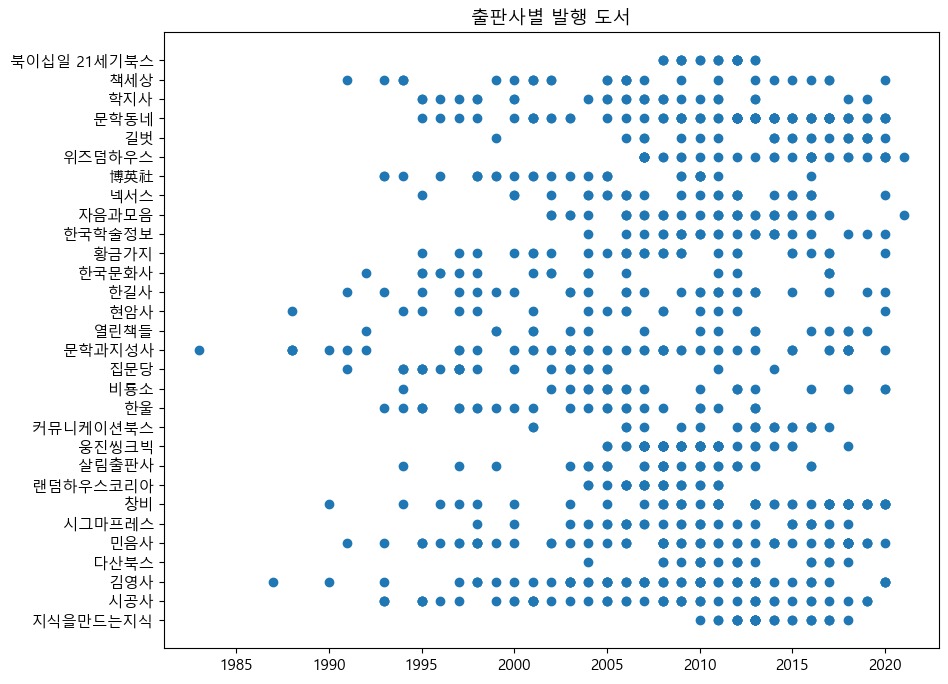

In [33]:
# 객체 지향 api 방식으로 산점도 그리기
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(ns_book8['발행년도'], ns_book8['출판사'])
ax.set_title('출판사별 발행 도서')
fig.show()

- `scatter()` 함수의 매개변수들
    - `s` 매개변수: 마커의 크기를 지정  
    - `alpha` 매개변수: 마커의 투명도 결정  
    - `edgecolor` 매개변수: 마커 테두리의 색 결정  
    - `linewidth` 매개변수: 마커 테두리 선의 두께 결정  
    - `c` 매개변수: 산점도의 색 지정 

C:\Users\user\AppData\Local\Temp\ipykernel_20340\1984904183.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


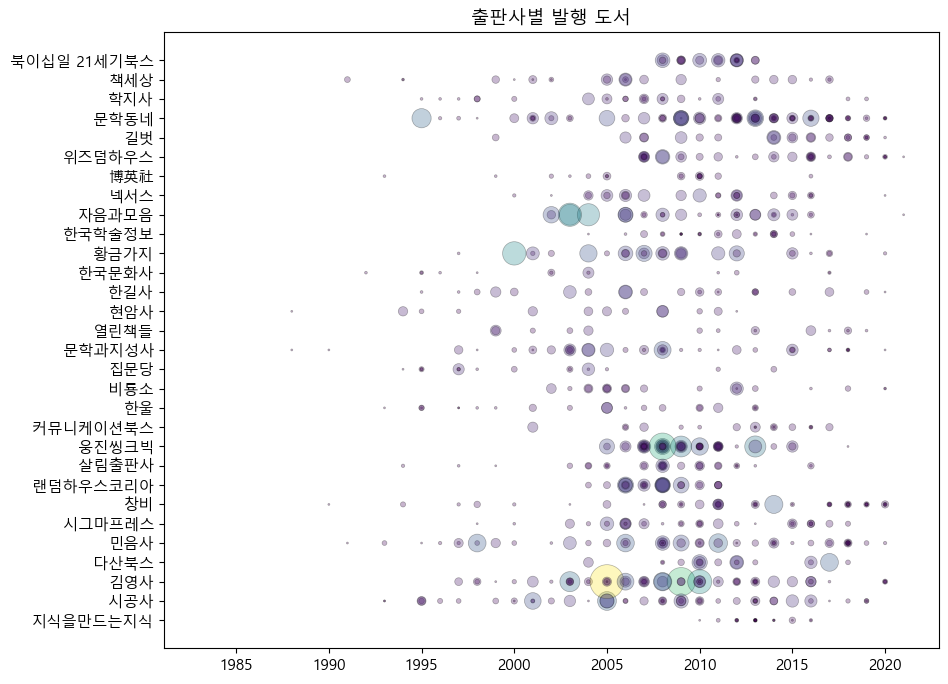

In [34]:
fig, ax = plt.subplots(figsize=(10,8))
ax.scatter(ns_book8['발행년도'], ns_book8['출판사'],
           linewidths=0.5, edgecolors='k', alpha=0.3,
           s=ns_book8['대출건수']*2, c=ns_book8['대출건수'])
ax.set_title('출판사별 발행 도서')
fig.show()